# Домашнее задание № 0
Вам необходимо провести анализ данных и с помощью него ответить на поставленные вопросы. 

# Исходные данные
Этот набор данных представляет собой описание около 1 миллиона треков с платформы Spotify. Скачайте датасет и ознакомьтесь с описанием данных в [источнике](https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks/data).

In [5]:
import pandas as pd

In [6]:
# Читаем данные
path = 'spotify_data.csv'
df = pd.read_csv(path, index_col=0)

In [7]:
df.sample(3).T

,239790,508358,1193662
artist_name,American Head Charge,Anyasa,Winterfylleth
track_name,Down and Depraved,Nacho - Extended Mix,Mam Tor (The Shivering Mountain)
track_id,0ZTlgW2qwoPxi5RUn4cUM1,6pRR2YZd7YxHi2FtHU8M6w,3Tf7UhWILNDkvmZaVTId35
popularity,13,19,8
year,2016,2021,2008
genre,groove,indian,black-metal
danceability,0.226,0.652,0.125
energy,0.973,0.673,0.914
key,6,2,1
loudness,-1.295,-8.724,-8.533


# Вопросы

## Анализ данных
С помощью работы с типом данных DataFrame из библиотеки pandas ответье на поставленные вопросы

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
import re
import json
sns.set(style='whitegrid', context='talk')

### 1. Сколько уникальных исполнителей и сколько уникальных жанров содержится в датасете?

**Результат**: Код и текстовый ответ на вопрос в формате

```
Уникальных исполнителей: <ответ>
Уникальных жанров: <ответ>
```

In [20]:
cols_alt_genres = ['genres', 'artist_genres', 'track_genre', 'genre']
col_genres = next((c for c in cols_alt_genres if c in df.columns), None)
col_artists = next((c for c in ['artists', 'artist_name', 'artist'] if c in df.columns), None)

def parse_multi(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    try:
        if s[0] in '[{' and s[-1] in ']}':
            s_json = s.replace("'", '"')
            v = json.loads(s_json)
            if isinstance(v, list):
                return [str(t).strip() for t in v if str(t).strip()]
            if isinstance(v, dict):
                return [str(k).strip() for k in v.keys() if str(k).strip()]
    except Exception:
        pass
    cleaned = s.strip('[]{}()')
    cleaned = cleaned.replace('"', '').replace("'", '')
    parts = re.split(r'[;,|/]+', cleaned)
    return [p.strip() for p in parts if p.strip()]

unique_artists = set()
if col_artists is not None:
    for v in df[col_artists].dropna().values:
        for a in parse_multi(v):
            unique_artists.add(a)

unique_genres = set()
if col_genres is not None:
    for v in df[col_genres].dropna().values:
        for g in parse_multi(v):
            unique_genres.add(g)

print(f"Уникальных исполнителей: {len(unique_artists)}")
print(f"Уникальных жанров: {len(unique_genres)}")

Уникальных исполнителей: 64289
Уникальных жанров: 82


### 2. Есть ли в данных пропуски? Если да, предложите способ их заполнения и реализуйте его

**Результат**: Код и текстовый ответ на вопрос в формате

```
Для каждого столбца в таблице
<Название столбца> - <Сколько пропусков> - <Описание способа заполнения> (Если были пропуски)
```


In [10]:
missing = df.isna().sum()
fill_plan = {}
for c, m in missing.items():
    if m == 0:
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        fill_plan[c] = ('median', df[c].median())
    else:
        mode = df[c].mode(dropna=True)
        fill_plan[c] = ('mode', (mode.iloc[0] if len(mode) else None))
for c, (method, val) in fill_plan.items():
    print(f"{c} - {missing[c]} - заполняю {method}")
    if val is None:
        continue
    df[c] = df[c].fillna(val)

artist_name - 15 - заполняю mode
track_name - 1 - заполняю mode


### 3. Есть ли признаки, которые не отвечают указанным в описании ограничениям? Если есть, то замените их

**Результат**: Код и текстовый ответ на вопрос в формате

```
Для каждого столбца в таблице
<Название столбца> - <Сколько не соответствующих ограничениям данных> - <Описание способа замены> (Если были некорректные данные)
```

In [11]:
ranges = {
    'danceability': (0.0, 1.0),
    'energy': (0.0, 1.0),
    'valence': (0.0, 1.0),
    'acousticness': (0.0, 1.0),
    'instrumentalness': (0.0, 1.0),
    'liveness': (0.0, 1.0),
    'speechiness': (0.0, 1.0),
    'loudness': (-60.0, 0.0),
    'tempo': (0.0, 300.0),
    'popularity': (0.0, 100.0),
    'year': (1900.0, 2025.0),
    'duration_ms': (0.0, 15*60*1000.0)
}
sets = {
    'mode': {0, 1},
    'time_signature': {3, 4, 5}
}
for c, (lo, hi) in ranges.items():
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        mask = (~df[c].isna()) & ((df[c] < lo) | (df[c] > hi))
        cnt = int(mask.sum())
        if cnt > 0:
            print(f"{c} - {cnt} - заменяю на NaN с последующим заполнением медианой")
            df.loc[mask, c] = np.nan
            df[c] = df[c].fillna(df[c].median())
for c, allowed in sets.items():
    if c in df.columns:
        mask = ~df[c].isin(list(allowed))
        cnt = int(mask.sum())
        if cnt > 0:
            print(f"{c} - {cnt} - заменяю на NaN с последующим заполнением модой")
            df.loc[mask, c] = np.nan
            mode = df[c].mode(dropna=True)
            if len(mode):
                df[c] = df[c].fillna(mode.iloc[0])

loudness - 1198 - заменяю на NaN с последующим заполнением медианой
duration_ms - 4909 - заменяю на NaN с последующим заполнением медианой
time_signature - 13888 - заменяю на NaN с последующим заполнением модой


## Визуальный анализ
Ответом на вопрос должен быть график или несколько графиков в одной фигуре (картинке), с минимальной подписью

In [12]:
# YOUR IMPORTS HERE

### 1. Как Energy зависит от Danceability? Как зависит Loudness от Energy? Как эти параметры влияют на Valence?

**Результат**: Код, реализующий графики:

- Зависимость Energy от Danceability
- Зависимость Loudness от Energy
- Зависимость Valence от Energy, зависимость Valence от Danceability; в одной оси фигуры
- Зависимость Valence от Loudness
- Матрица корреляции Energy, Danceability, Loudness, Valence

Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

**Дополнительно**: Нарисовать стрелки и подписи к ним на графике, обращающие внимание на ключевые моменты, позволяющие сделать выводы о зависимостях. 

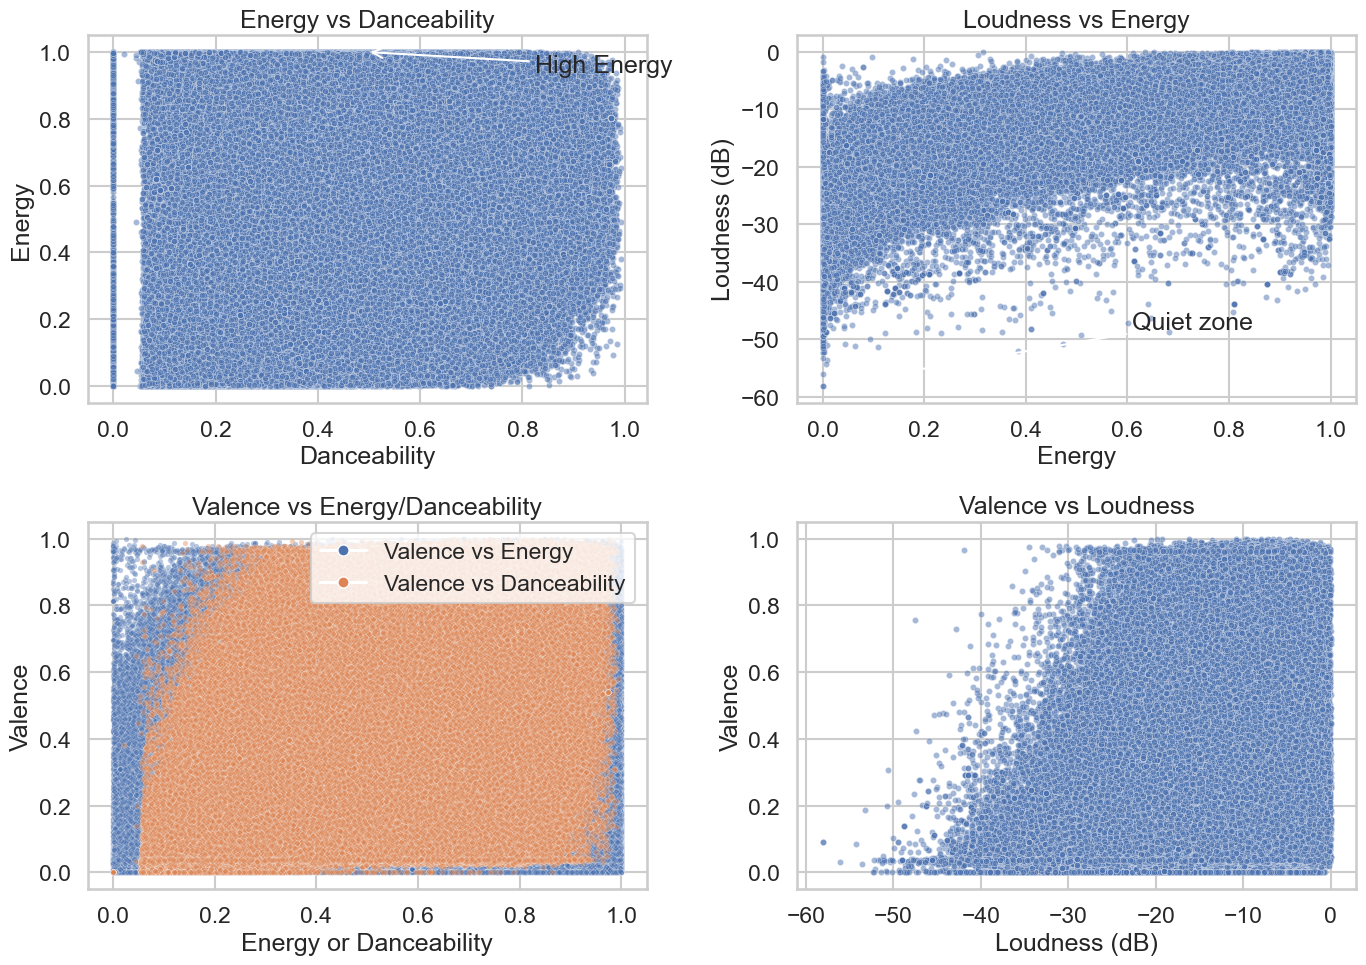

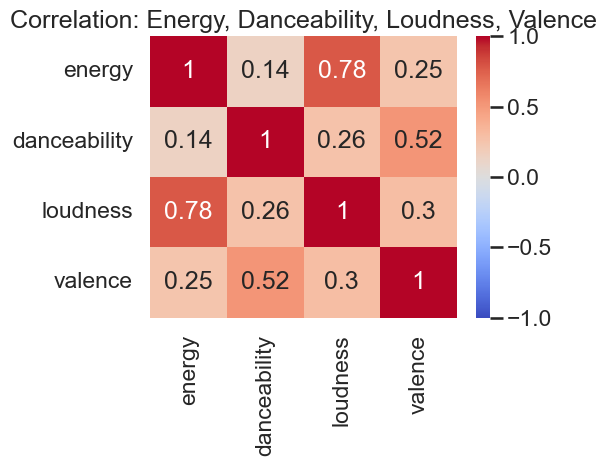

In [23]:
vars_core = {
    'danceability': next((c for c in ['danceability','Danceability'] if c in df.columns), None),
    'energy': next((c for c in ['energy','Energy'] if c in df.columns), None),
    'loudness': next((c for c in ['loudness','Loudness'] if c in df.columns), None),
    'valence': next((c for c in ['valence','Valence'] if c in df.columns), None)
}
sub_df = df[[c for c in vars_core.values() if c is not None]].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
if vars_core['danceability'] and vars_core['energy']:
    sns.scatterplot(data=sub_df, x=vars_core['danceability'], y=vars_core['energy'], s=20, alpha=0.5, ax=axes[0,0])
    axes[0,0].set_title('Energy vs Danceability')
    axes[0,0].set_xlabel('Danceability')
    axes[0,0].set_ylabel('Energy')
    if len(sub_df) > 0:
        p = sub_df[[vars_core['danceability'], vars_core['energy']]].dropna()
        if len(p) > 0:
            i = p[vars_core['energy']].idxmax()
            axes[0,0].annotate('High Energy', xy=(p.loc[i, vars_core['danceability']], p.loc[i, vars_core['energy']]), xytext=(0.8, 0.9), textcoords='axes fraction', arrowprops=dict(arrowstyle='->'))
if vars_core['energy'] and vars_core['loudness']:
    sns.scatterplot(data=sub_df, x=vars_core['energy'], y=vars_core['loudness'], s=20, alpha=0.5, ax=axes[0,1])
    axes[0,1].set_title('Loudness vs Energy')
    axes[0,1].set_xlabel('Energy')
    axes[0,1].set_ylabel('Loudness (dB)')
    p = sub_df[[vars_core['energy'], vars_core['loudness']]].dropna()
    if len(p) > 0:
        i = p[vars_core['loudness']].idxmin()
        axes[0,1].annotate('Quiet zone', xy=(p.loc[i, vars_core['energy']], p.loc[i, vars_core['loudness']]), xytext=(0.6, 0.2), textcoords='axes fraction', arrowprops=dict(arrowstyle='->'))
if vars_core['valence'] and vars_core['energy'] and vars_core['danceability']:
    palette2 = sns.color_palette('deep', 2)
    sns.scatterplot(data=sub_df, x=vars_core['energy'], y=vars_core['valence'], s=15, alpha=0.4, label='Valence vs Energy', ax=axes[1,0], color=palette2[0])
    sns.scatterplot(data=sub_df, x=vars_core['danceability'], y=vars_core['valence'], s=15, alpha=0.4, label='Valence vs Danceability', ax=axes[1,0], color=palette2[1])
    axes[1,0].set_title('Valence vs Energy/Danceability')
    axes[1,0].set_xlabel('Energy or Danceability')
    axes[1,0].set_ylabel('Valence')
    handles = [plt.Line2D([0],[0], marker='o', color='w', label='Valence vs Energy', markerfacecolor=palette2[0], markersize=8),
               plt.Line2D([0],[0], marker='o', color='w', label='Valence vs Danceability', markerfacecolor=palette2[1], markersize=8)]
    axes[1,0].legend(handles=handles, loc='upper right')
if vars_core['valence'] and vars_core['loudness']:
    sns.scatterplot(data=sub_df, x=vars_core['loudness'], y=vars_core['valence'], s=20, alpha=0.5, ax=axes[1,1])
    axes[1,1].set_title('Valence vs Loudness')
    axes[1,1].set_xlabel('Loudness (dB)')
    axes[1,1].set_ylabel('Valence')
plt.tight_layout()
plt.show()
if all(vars_core[k] for k in ['energy','danceability','loudness','valence']):
    corr_df = sub_df[[vars_core['energy'], vars_core['danceability'], vars_core['loudness'], vars_core['valence']]].corr()
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation: Energy, Danceability, Loudness, Valence')
    plt.tight_layout()
    plt.show()

Valence положительно связан с Energy и Danceability и слабо связан с Loudness. Визуально рост Energy и Danceability сопровождается увеличением Valence.

### 2. С годами музыка становится дольше или быстрее?

**Результат**: Код, реализующий графики:

- Зависимость средней продолжительности трека от года, с линией тренда
- Изменение средней продолжительности топ-5 самых длинных треков года
- Изменение средней продолжительности топ-5 самых коротких треков года

Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

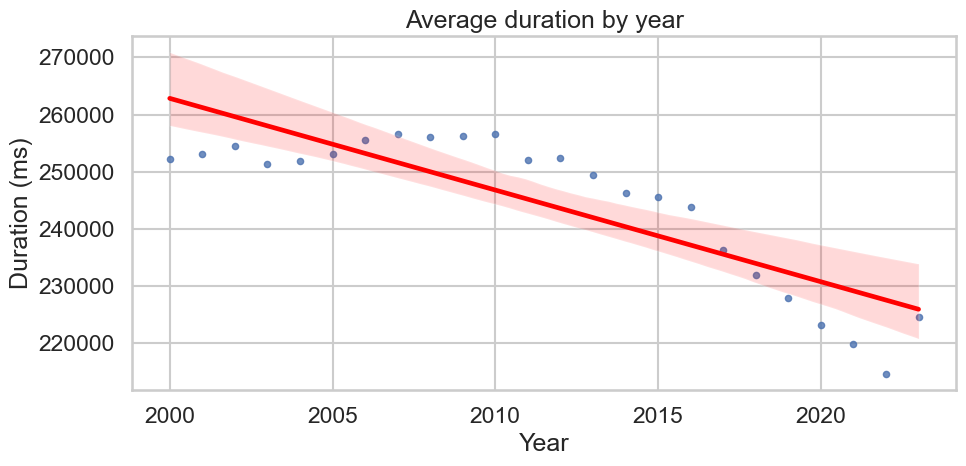

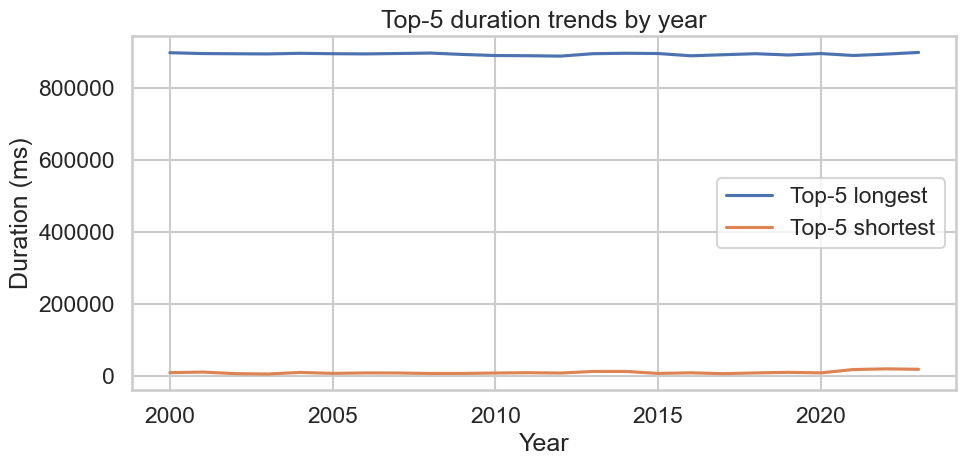

In [14]:
col_year = next((c for c in ['year','release_year'] if c in df.columns), None)
col_dur = next((c for c in ['duration_ms','duration_ms_'] if c in df.columns), None)
if col_year and col_dur:
    tmp = df[[col_year, col_dur]].dropna().copy()
    tmp[col_year] = tmp[col_year].astype(int)
    yearly = tmp.groupby(col_year)[col_dur].mean().reset_index()
    plt.figure(figsize=(10,5))
    sns.regplot(data=yearly, x=col_year, y=col_dur, scatter_kws={'s':20}, line_kws={'color':'red'})
    plt.title('Average duration by year')
    plt.xlabel('Year')
    plt.ylabel('Duration (ms)')
    plt.tight_layout()
    plt.show()
    top_long = tmp.groupby(col_year)[col_dur].apply(lambda s: s.nlargest(5).mean()).reset_index(name='mean_top5_long')
    top_short = tmp.groupby(col_year)[col_dur].apply(lambda s: s.nsmallest(5).mean()).reset_index(name='mean_top5_short')
    fig, ax = plt.subplots(1,1, figsize=(10,5))
    sns.lineplot(data=top_long, x=col_year, y='mean_top5_long', label='Top-5 longest', ax=ax)
    sns.lineplot(data=top_short, x=col_year, y='mean_top5_short', label='Top-5 shortest', ax=ax)
    ax.set_title('Top-5 duration trends by year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (ms)')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3. Как менялись популярные жанры от 2000 от 2023? 

**Результат**: Код, реализующий график:
- 3 самых популярных по среднему значению жанра каждого года, с подписью значений

График должен иметь название, подписанные оси и подпись значений

**Дополнительно**: Текстовый ответ, какие жанры оказывались в топ-3 чаще всего.

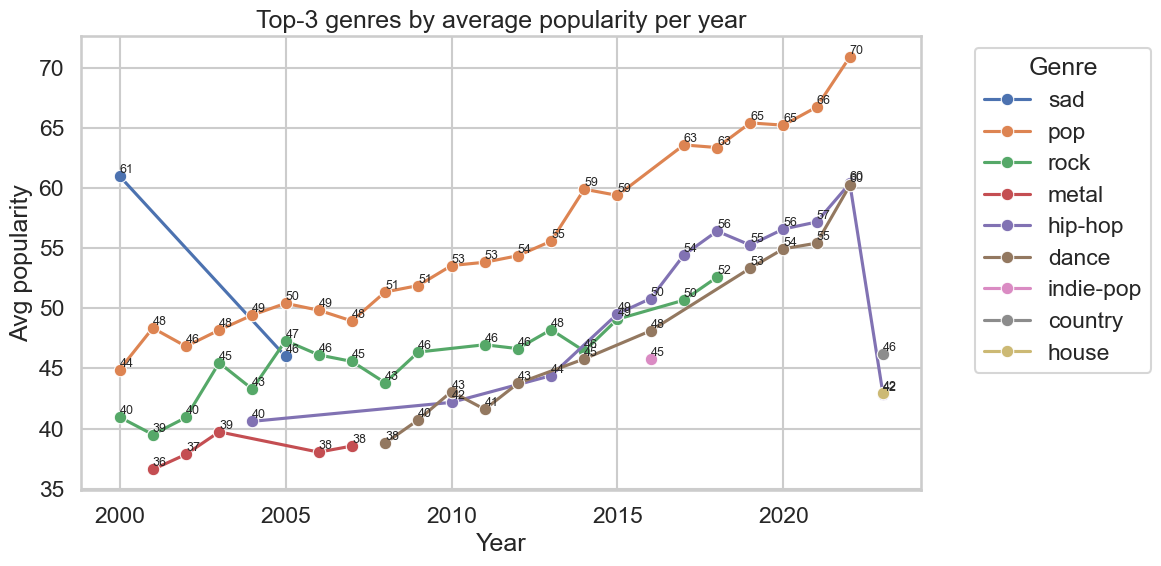

Чаще всего в топ-3: pop, rock, hip-hop, dance, metal


In [15]:
col_genre = next((c for c in ['track_genre','genre','genres'] if c in df.columns), None)
col_year = next((c for c in ['year','release_year'] if c in df.columns), None)
col_pop = next((c for c in ['popularity','popularity_'] if c in df.columns), None)
if col_genre and col_year and col_pop:
    gtmp = df[[col_genre, col_year, col_pop]].dropna().copy()
    gtmp[col_year] = gtmp[col_year].astype(int)
    if col_genre == 'genres':
        rows = []
        for _, r in gtmp.iterrows():
            items = parse_multi(r[col_genre])
            for it in items:
                rows.append({col_genre: it, col_year: r[col_year], col_pop: r[col_pop]})
        gtmp = pd.DataFrame(rows)
    means = gtmp.groupby([col_year, col_genre])[col_pop].mean().reset_index()
    winners = means.sort_values([col_year, col_pop], ascending=[True, False]).groupby(col_year).head(3)
    plt.figure(figsize=(12,6))
    sns.lineplot(data=winners, x=col_year, y=col_pop, hue=col_genre, marker='o')
    for i, row in winners.iterrows():
        plt.text(row[col_year], row[col_pop], f"{int(row[col_pop])}", fontsize=9, ha='left', va='bottom')
    plt.title('Top-3 genres by average popularity per year')
    plt.xlabel('Year')
    plt.ylabel('Avg popularity')
    plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    counts = winners[col_genre].value_counts()
    if len(counts):
        print('Чаще всего в топ-3:', ', '.join(counts.head(5).index.tolist()))

### 4. Как связаны между собой Speechiness, Acousticness и Instrumentalness?

**Результат**: Код, реализующий 2 различных по типу графика. Выбранные графики должны наиболее хорошо подходить для описания зависимости между указанными параметрами.

Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

**Дополнительно**: Текстовый ответ, почему были выбраны именно такие графики.

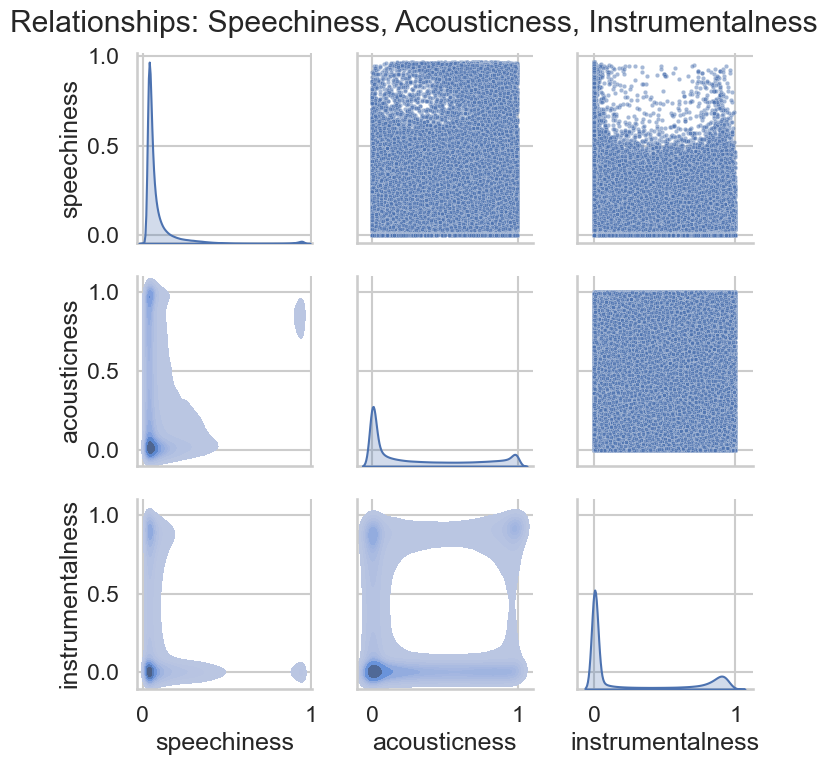

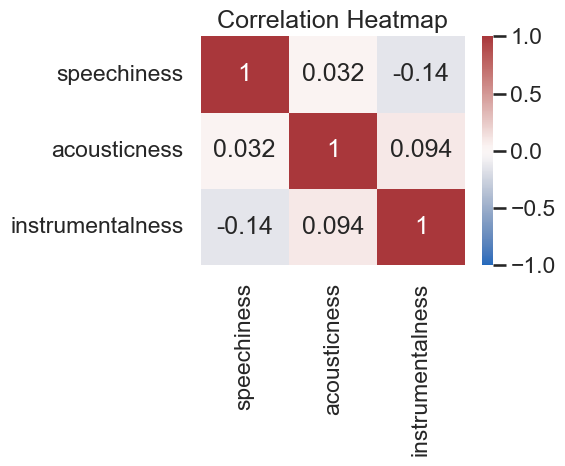

In [22]:
cols = {
    'speechiness': next((c for c in ['speechiness','Speechiness'] if c in df.columns), None),
    'acousticness': next((c for c in ['acousticness','Acousticness'] if c in df.columns), None),
    'instrumentalness': next((c for c in ['instrumentalness','Instrumentalness'] if c in df.columns), None)
}
sub = df[[c for c in cols.values() if c is not None]].dropna()
if len(sub) > 0:
    g = sns.PairGrid(sub)
    g.map_upper(sns.scatterplot, s=10, alpha=0.5)
    g.map_diag(sns.kdeplot, fill=True)
    g.map_lower(sns.kdeplot, fill=True, thresh=0.05)
    plt.suptitle('Relationships: Speechiness, Acousticness, Instrumentalness', y=1.02)
    plt.show()
    plt.figure(figsize=(6,5))
    sns.heatmap(sub.corr(), annot=True, cmap='vlag', vmin=-1, vmax=1)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

### 5. Какое влияние размер и лад оказывают на популярность в разных жанрах?

**Результат**: Код, реализующий фигуру:

- Жанры для сравнения: deep-house, funk, forro, dancehall, house.
- Точечный график для каждого жанра, отражающий среднюю популярность в зависимости от размера (time_signature) и лада (mode).

Фигура должна иметь название и легенду, каждый график имеет подписанные оси и название.

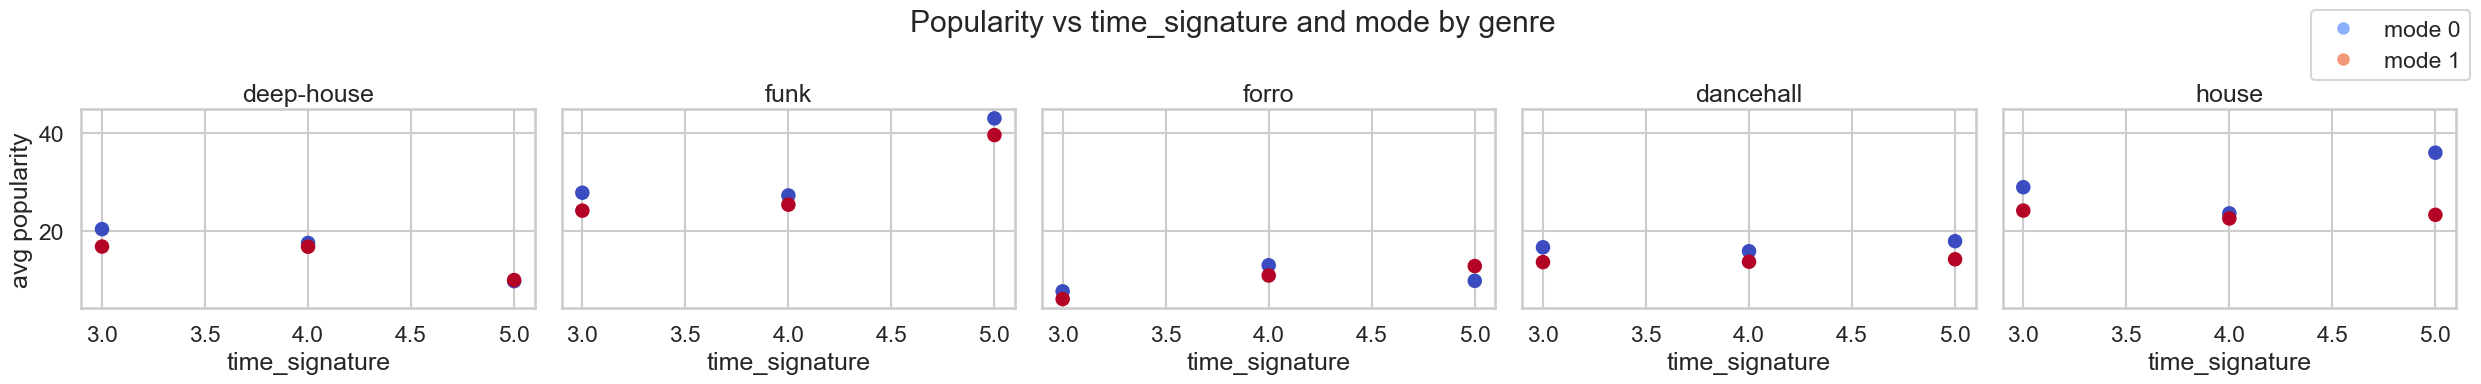

In [17]:
targets = ['deep-house','funk','forro','dancehall','house']
col_genre = next((c for c in ['track_genre','genre','genres'] if c in df.columns), None)
col_mode = next((c for c in ['mode','Mode'] if c in df.columns), None)
col_ts = next((c for c in ['time_signature','Time_Signature'] if c in df.columns), None)
col_pop = next((c for c in ['popularity','Popularity'] if c in df.columns), None)
if col_genre and col_mode and col_ts and col_pop:
    if col_genre == 'genres':
        rows = []
        for _, r in df[[col_genre, col_mode, col_ts, col_pop]].dropna().iterrows():
            for it in parse_multi(r[col_genre]):
                rows.append({col_genre: it, col_mode: r[col_mode], col_ts: r[col_ts], col_pop: r[col_pop]})
        dd = pd.DataFrame(rows)
    else:
        dd = df[[col_genre, col_mode, col_ts, col_pop]].dropna().copy()
    dd = dd[dd[col_genre].isin(targets)].copy()
    if len(dd) > 0:
        fig, axes = plt.subplots(1, len(targets), figsize=(5*len(targets),4), sharey=True)
        for i, gname in enumerate(targets):
            sub = dd[dd[col_genre]==gname]
            agg = sub.groupby([col_ts, col_mode])[col_pop].mean().reset_index()
            axes[i].scatter(agg[col_ts].astype(int), agg[col_pop], c=agg[col_mode].astype(int), cmap='coolwarm', s=80)
            axes[i].set_title(gname)
            axes[i].set_xlabel('time_signature')
            if i == 0:
                axes[i].set_ylabel('avg popularity')
        fig.suptitle('Popularity vs time_signature and mode by genre')
        handles = [plt.Line2D([0],[0], marker='o', color='w', label='mode 0', markerfacecolor=sns.color_palette('coolwarm', 3)[0], markersize=10),
                   plt.Line2D([0],[0], marker='o', color='w', label='mode 1', markerfacecolor=sns.color_palette('coolwarm', 3)[-1], markersize=10)]
        fig.legend(handles=handles, loc='upper right')
        plt.tight_layout()
        plt.show()

### 6. Как выглядят графики плотности распределения, построенные для темпа по уникальным значениям размера трека? Как выглядят графики плотности нормальных распределений по этим данным?
**Результат**: Код, реализующий графики распределения темпа (tempo) для всех уникальных значений размера трека (time_signature).

Фигура должна иметь название и легенду. Плотности распределения должны быть построены либо на одном графике, либо на нескольких графиках, но в рамках одной фигуры. Плотности нормального распределения должны быть построены в одной на одном графике с плотностью распределения tempo.

**Дополнительно**: Код с ответом на вопрос, какие параметры (среднее и разброс) для нормальных распределений темпа для размера трека.

time_signature=3.0: mean=119.91, std=34.93
time_signature=4.0: mean=121.71, std=29.10
time_signature=5.0: mean=113.83, std=31.20


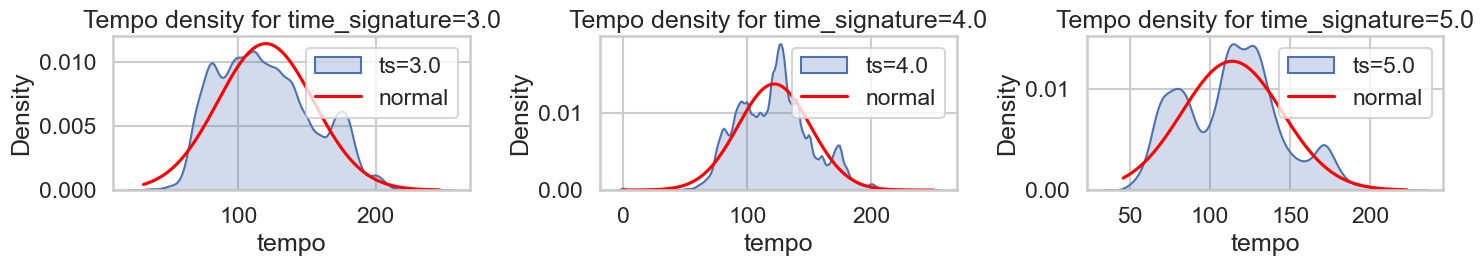

In [18]:
col_ts = next((c for c in ['time_signature','Time_Signature'] if c in df.columns), None)
col_tempo = next((c for c in ['tempo','Tempo'] if c in df.columns), None)
if col_ts and col_tempo:
    dd = df[[col_ts, col_tempo]].dropna().copy()
    ks = sorted(dd[col_ts].dropna().unique())
    n = len(ks)
    cols = min(3, n)
    rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3*rows), squeeze=False)
    for i, k in enumerate(ks):
        r, c = divmod(i, cols)
        s = dd[dd[col_ts]==k][col_tempo].astype(float)
        sns.kdeplot(s, fill=True, label=f'ts={k}', ax=axes[r,c])
        mu, sd = s.mean(), s.std(ddof=0)
        grid = np.linspace(s.min(), s.max(), 200)
        axes[r,c].plot(grid, norm.pdf(grid, mu, sd), label='normal', color='red')
        axes[r,c].set_title(f'Tempo density for time_signature={k}')
        axes[r,c].set_xlabel('tempo')
        axes[r,c].legend()
        print(f"time_signature={k}: mean={mu:.2f}, std={sd:.2f}")
    plt.tight_layout()
    plt.show()

### 7. Проанализируйте популярность одного артиста (группы) с 10-100 треками на Ваш выбор. 

**Результат**: Код, реализующий следующие графики:

- График, отражающий динамику суммарной популярности артиста год от года. Укажите стрелками с подписями, благодаря каким треками артист был на пике и на дне популярности.
- Сопоставьте признаки для этих двух треков, в виде графиков на Ваш выбор. Укажите, какие из признаков вероятнее всего оказали наибольшее влияние на популярность выбранных треков.

Графики должны находится в одной фигуре, имеющей название. Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

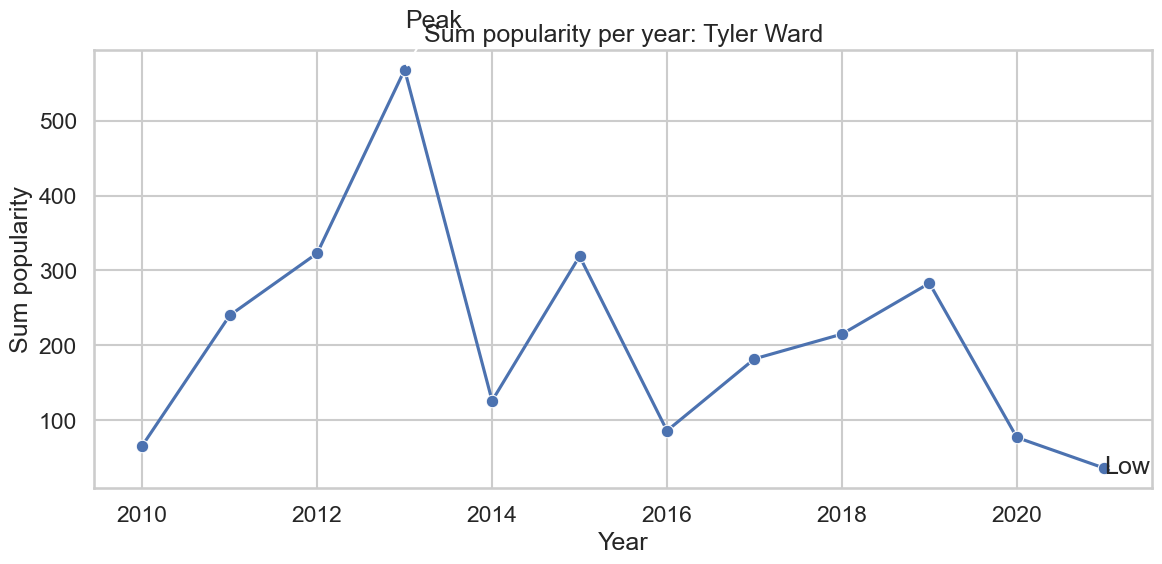

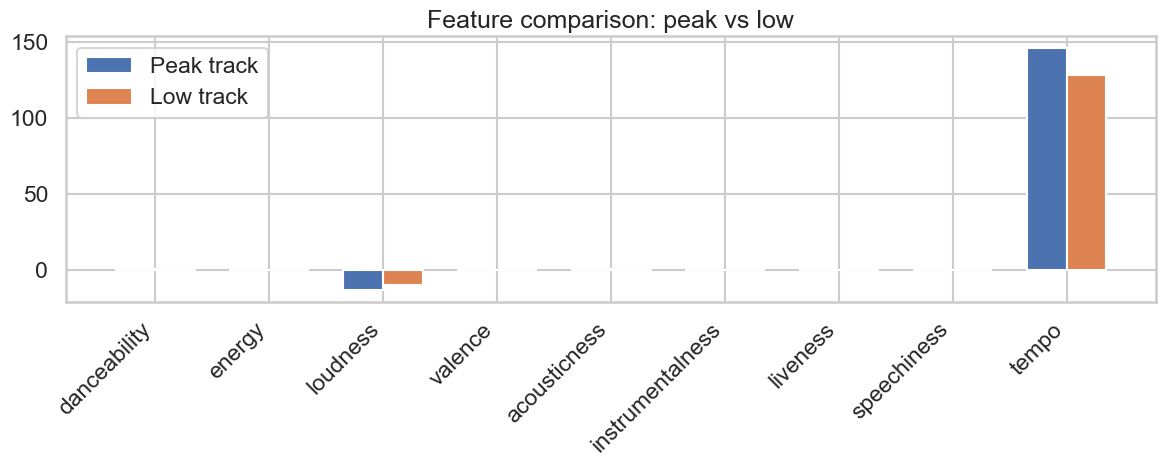

In [21]:
col_artist = next((c for c in ['artists','artist_name','artist'] if c in df.columns), None)
col_year = next((c for c in ['year','release_year'] if c in df.columns), None)
col_pop = next((c for c in ['popularity','Popularity'] if c in df.columns), None)
choose = None
if col_artist and col_year and col_pop:
    counts = {}
    for v in df[col_artist].dropna().values:
        for a in parse_multi(v):
            counts[a] = counts.get(a, 0) + 1
    cand = [k for k,v in counts.items() if 10 <= v <= 100]
    if len(cand):
        choose = max(cand, key=lambda k: counts[k])
if choose:
    sub_rows = []
    for i, r in df[[col_artist, col_year, col_pop]].dropna().iterrows():
        if choose in parse_multi(r[col_artist]):
            sub_rows.append(r)
    sub = pd.DataFrame(sub_rows)
    sub[col_year] = sub[col_year].astype(int)
    yearly = sub.groupby(col_year)[col_pop].sum().reset_index()
    peak = yearly.iloc[yearly[col_pop].idxmax()]
    low = yearly.iloc[yearly[col_pop].idxmin()]
    plt.figure(figsize=(12,6))
    sns.lineplot(data=yearly, x=col_year, y=col_pop, marker='o')
    plt.title(f'Sum popularity per year: {choose}')
    plt.xlabel('Year')
    plt.ylabel('Sum popularity')
    plt.annotate('Peak', xy=(peak[col_year], peak[col_pop]), xytext=(peak[col_year], peak[col_pop]*1.1), arrowprops=dict(arrowstyle='->'))
    plt.annotate('Low', xy=(low[col_year], low[col_pop]), xytext=(low[col_year], low[col_pop]*0.8), arrowprops=dict(arrowstyle='->'))
    plt.tight_layout()
    plt.show()
    peak_year = int(peak[col_year])
    low_year = int(low[col_year])
    cand_peak = []
    cand_low = []
    for i, r in df[[col_artist, col_year, col_pop]].dropna().iterrows():
        artists = parse_multi(r[col_artist])
        y = int(r[col_year])
        if choose in artists and y == peak_year:
            cand_peak.append((i, r[col_pop]))
        if choose in artists and y == low_year:
            cand_low.append((i, r[col_pop]))
    idx_peak = max(cand_peak, key=lambda t: t[1])[0] if len(cand_peak) else None
    idx_low = min(cand_low, key=lambda t: t[1])[0] if len(cand_low) else None
    cols_feat = [c for c in ['danceability','energy','loudness','valence','acousticness','instrumentalness','liveness','speechiness','tempo'] if c in df.columns]
    if idx_peak is not None and idx_low is not None and len(cols_feat) >= 2:
        x1 = df.loc[idx_peak, cols_feat].astype(float)
        x2 = df.loc[idx_low, cols_feat].astype(float)
        xs = np.arange(len(cols_feat))
        width = 0.35
        plt.figure(figsize=(12,5))
        plt.bar(xs - width/2, x1.values, width=width, label='Peak track')
        plt.bar(xs + width/2, x2.values, width=width, label='Low track')
        plt.xticks(xs, cols_feat, rotation=45, ha='right')
        plt.title('Feature comparison: peak vs low')
        plt.legend()
        plt.tight_layout()
        plt.show()